In [5]:
import pandas as pd
import geopandas as gpd
import numpy as np
import pymc as pm
import arviz as az
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("../data/cleaned_ECEC_labour_2022 dataset.csv")

excluded_cols = ['prov', 'fem_empl_rate', 'urban_type']
df = df.drop(columns=excluded_cols)

In [7]:
corr_matrix = df.corr()

# avoid duplicate pairs and self-correlation
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

threshold = 0.89

high_corr_pairs = (
    upper.stack()
         .reset_index()
         .rename(columns={'level_0': 'var1', 'level_1': 'var2', 0: 'corr'})
)

high_corr_pairs = (
    high_corr_pairs[high_corr_pairs['corr'].abs() >= threshold]
    .sort_values(by='corr', key=np.abs, ascending=False)
)

In [8]:
print("Highly correlated pairs")
print(high_corr_pairs.to_string(index=False, float_format=lambda x: f"{x: .3f}"))

Highly correlated pairs
                              var1                         var2   corr
other_percapita_public_expenditure other_per_capita_expenditure  0.995
                         empl_rate                   inact_rate -0.989
                net_migration_rate       adj_net_migration_rate  0.985
                         part_rate                   inact_rate -0.978
                         part_rate                    empl_rate  0.973
                      fem_edu_rate                male_edu_rate  0.952
                       unempl_rate                    empl_rate -0.918
                         empl_rate                   young_neet -0.900


In [9]:
var_counts = (
    pd.concat([high_corr_pairs["var1"], high_corr_pairs["var2"]])
      .value_counts()
)

var_presence_list = list(var_counts.items())

for var, count in var_presence_list:
    print(f"({var}, {count})")

(empl_rate, 4)
(inact_rate, 2)
(part_rate, 2)
(net_migration_rate, 1)
(other_percapita_public_expenditure, 1)
(unempl_rate, 1)
(fem_edu_rate, 1)
(other_per_capita_expenditure, 1)
(adj_net_migration_rate, 1)
(male_edu_rate, 1)
(young_neet, 1)


In [10]:
# we will talk about which one actually to drop

var_to_drop = ['empl_rate', 'inact_rate', 'male_edu_rate', 'other_per_capita_expenditure', 'adj_net_migration_rate']

df_reduced = df.drop(columns=var_to_drop)

# Other variables to consider dropping based on domain knowledge
to_drop = ['part_rate', 'unempl_rate']

df_reduced = df_reduced.drop(columns=to_drop)

In [11]:
selected_covariates = list(df_reduced.columns)

df_full = pd.read_csv("../data/cleaned_ECEC_labour_2022 dataset.csv")
target_col = "fem_empl_rate"

df_model = df_full[[target_col] + selected_covariates].dropna()

print("Selected covariates used in the model:")
print(selected_covariates)


X = df_model[selected_covariates].to_numpy()
y = df_model[target_col].to_numpy()


# standardize predictors and the target
X_scaler = StandardScaler()
X_scaled = X_scaler.fit_transform(X)

y_mean = y.mean()
y_std = y.std()
y = y / 100
y_scaled = np.log(y / (1 - y))

n_obs, n_feat = X_scaled.shape
print(f"\nNumber of observations: {n_obs}, number of predictors: {n_feat}")


Selected covariates used in the model:
['population', 'empl_growth', 'fem_edu_rate', 'service_empl_rate', 'GDP', 'n_large_comp', 'n_self_empl', 'young_neet', 'fem_house_rate', 'foreign_rate', 'n_members_family', 'elderly_in_care', 'house_price', 'fertility_rate', 'first_birth_maternal_age', 'avg_children_per_woman', 'dependency_rate', 'ageing_index', 'net_migration_rate', 'area_km2', 'public_transport_supply', 'internet_coverage_rate', 'graduate_mobility_rate', 'green_m2_capita', 'eco_urban_index', 'per_capita_public_expenditure', 'ecec_participation', 'coverage', 'per_capita_user_contribution', 'advanced_business_empl', 'lifelong_learn', 'startup_ratio', 'GERD_total_intramural', 'public_coverage', 'private_coverage', 'other_percapita_public_expenditure', 'other_percapita_user_contrib', 'fem_maj_empl_rate']

Number of observations: 107, number of predictors: 38


In [12]:
print("X_data shape:", X_scaled.shape)
print("y_data shape:", y_scaled.shape)

X_data shape: (107, 38)
y_data shape: (107,)


In [13]:
with pm.Model() as bl_model:
    X_data = pm.Data("X_data", X_scaled)
    y_data = pm.Data("y_data", y_scaled)

    lambda_ = pm.Gamma("lambda", alpha=0.1, beta=0.1)
    sigma = pm.HalfNormal("sigma", sigma=1.0)

    beta = pm.Laplace(
        "beta",
        mu=0.0,
        b=sigma / lambda_,
        shape=n_feat
    )

    mu = pm.math.dot(X_data, beta)

    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_data)

    trace = pm.sample(
        draws=2000,
        tune=2000,
        target_accept=0.9,
        return_inferencedata=True,
        random_seed=42
    )

Initializing NUTS using jitter+adapt_diag...



You can find the C code in this temporary file: /tmp/pytensor_compilation_error_y815nwyz


CompileError: Compilation failed (return status=1):
/usr/bin/g++ -shared -g -Wno-c++11-narrowing -fno-exceptions -fno-unwind-tables -fno-asynchronous-unwind-tables -march=haswell -mmmx -mpopcnt -msse -msse2 -msse3 -mssse3 -msse4.1 -msse4.2 -mavx -mavx2 -mno-sse4a -mno-fma4 -mno-xop -mfma -mno-avx512f -mbmi -mbmi2 -maes -mpclmul -mno-avx512vl -mno-avx512bw -mno-avx512dq -mno-avx512cd -mno-avx512er -mno-avx512pf -mno-avx512vbmi -mno-avx512ifma -mno-avx5124vnniw -mno-avx5124fmaps -mno-avx512vpopcntdq -mno-avx512vbmi2 -mno-gfni -mno-vpclmulqdq -mno-avx512vnni -mno-avx512bitalg -mno-avx512bf16 -mno-avx512vp2intersect -mno-3dnow -mno-adx -mabm -mno-cldemote -mno-clflushopt -mno-clwb -mno-clzero -mcx16 -mno-enqcmd -mf16c -mfsgsbase -mfxsr -mno-hle -msahf -mno-lwp -mlzcnt -mmovbe -mno-movdir64b -mno-movdiri -mno-mwaitx -mno-pconfig -mno-pku -mno-prefetchwt1 -mno-prfchw -mno-ptwrite -mno-rdpid -mrdrnd -mno-rdseed -mno-rtm -mno-serialize -mno-sgx -mno-sha -mno-shstk -mno-tbm -mno-tsxldtrk -mno-v

In [ ]:
summary_beta_95 = az.summary(trace, var_names=["beta"], hdi_prob=0.95)

summary_beta_95.index = selected_covariates

summary_beta_95["contains_zero"] = (
    (summary_beta_95["hdi_2.5%"] <= 0) &
    (summary_beta_95["hdi_97.5%"] >= 0)
)

summary_beta_95 = summary_beta_95.sort_values("mean", key=np.abs, ascending=False)

print(summary_beta_95[["mean", "hdi_2.5%", "hdi_97.5%", "contains_zero"]])

                                     mean  hdi_2.5%  hdi_97.5%  contains_zero
fem_house_rate                     -0.308    -0.377     -0.239          False
ageing_index                        0.106     0.022      0.185          False
fertility_rate                     -0.102    -0.179     -0.022          False
young_neet                         -0.057    -0.102     -0.010          False
graduate_mobility_rate              0.044    -0.011      0.102           True
GDP                                 0.027    -0.023      0.082           True
fem_edu_rate                       -0.025    -0.062      0.007           True
internet_coverage_rate             -0.022    -0.047      0.002           True
coverage                            0.022    -0.029      0.086           True
avg_children_per_woman             -0.020    -0.070      0.020           True
private_coverage                    0.020    -0.025      0.067           True
per_capita_user_contribution        0.018    -0.017      0.059  

In [ ]:
summary_beta_95 = az.summary(trace, var_names=["beta"], hdi_prob=0.90)

summary_beta_95.index = selected_covariates

summary_beta_95["contains_zero"] = (
    (summary_beta_95["hdi_5%"] <= 0) &
    (summary_beta_95["hdi_95%"] >= 0)
)

summary_beta_95 = summary_beta_95.sort_values("mean", key=np.abs, ascending=False)

print(summary_beta_95[["mean", "hdi_5%", "hdi_95%", "contains_zero"]])

                                     mean  hdi_5%  hdi_95%  contains_zero
fem_house_rate                     -0.308  -0.364   -0.249          False
ageing_index                        0.106   0.034    0.169          False
fertility_rate                     -0.102  -0.162   -0.030          False
young_neet                         -0.057  -0.094   -0.016          False
graduate_mobility_rate              0.044  -0.006    0.092           True
GDP                                 0.027  -0.013    0.074           True
fem_edu_rate                       -0.025  -0.054    0.004           True
internet_coverage_rate             -0.022  -0.042    0.000           True
coverage                            0.022  -0.021    0.071           True
avg_children_per_woman             -0.020  -0.060    0.014           True
private_coverage                    0.020  -0.016    0.060           True
per_capita_user_contribution        0.018  -0.013    0.051           True
empl_growth                         0.

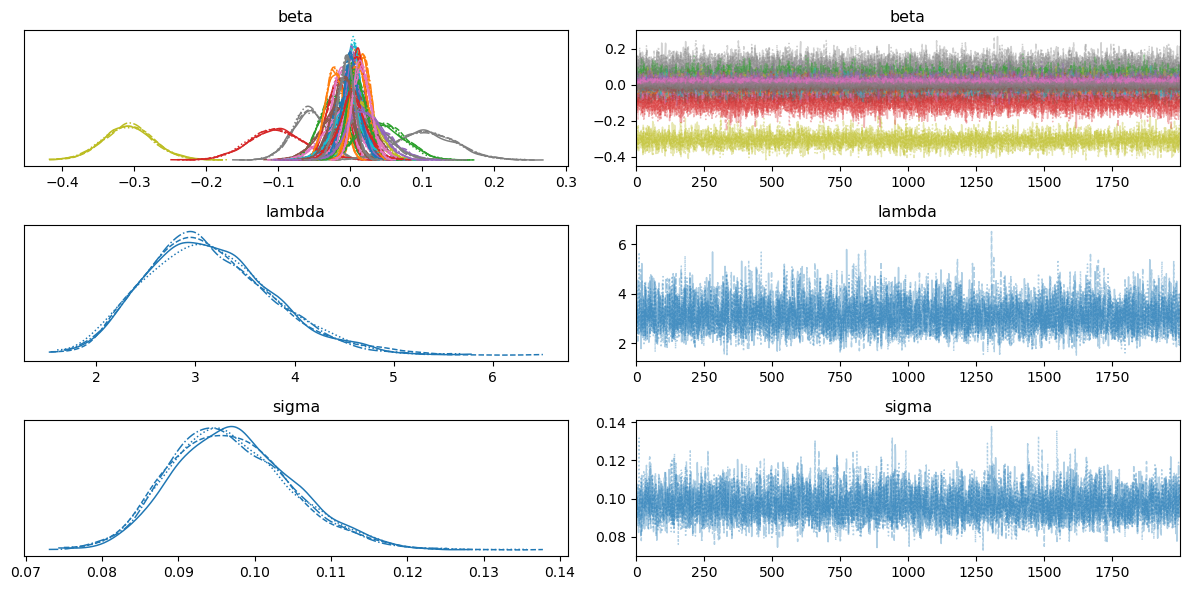

In [ ]:
# az.rcParams["plot.max_subplots"] = 100   
# az.plot_trace(trace, compact=False)

az.plot_trace(trace)
plt.tight_layout()

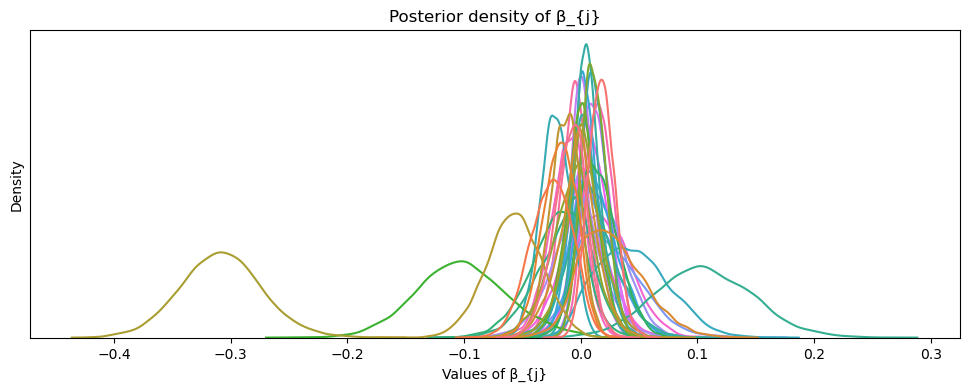

In [ ]:
beta_samples = trace.posterior["beta"].stack(samples=("chain", "draw")).values

plt.figure(figsize=(12,4))
sns.kdeplot(beta_samples.T, legend=False)
plt.title("Posterior density of β_{j}")
plt.xlabel("Values of β_{j}")
plt.yticks([])     
plt.gca().tick_params(axis='y', length=0)

plt.show()

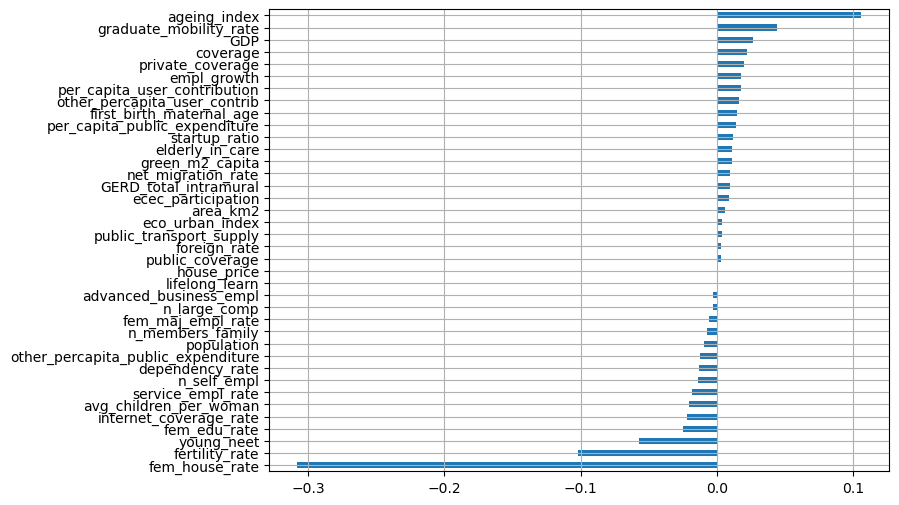

In [ ]:
plt.figure(figsize=(8,6))
summary_beta_95["mean"].sort_values().plot(kind='barh')
plt.grid(True)
plt.show()